# HYDROGEL Strategy Review

Review of quick `HYDROGEL_PACK` market-making trials run with:

```bash
prosperity4btx trader_r3_init.py 3
```

The implemented strategy keeps all logic inside `HydrogelStrategy`: raw `wall_mid` is used for active taking and zero-EV flush, while passive quotes use a nonlinear inventory-skewed fair value.


## Current Implementation

Baseline left in `trader_r3_init.py`:

- `take_edge = 2`
- `make_edge = 3`
- `max_skew_ticks = 4.0`
- `dead_zone = 0.50`
- `power = 2.0`

Interpretation: the first 50% of inventory capacity is treated as a normal spread-earning zone. Once inventory moves beyond that, skew grows quadratically and pushes passive quotes toward de-risking.


In [10]:
import pandas as pd

results = pd.DataFrame([
    {
        "trial": "baseline",
        "take_edge": 2,
        "make_edge": 3,
        "max_skew_ticks": 4.0,
        "dead_zone": 0.50,
        "day0": 10069,
        "day1": 12662,
        "day2": -590,
        "total": 22141,
        "log": "backtests/2026-04-25_10-58-52.log",
    },
    {
        "trial": "make_edge_2",
        "take_edge": 2,
        "make_edge": 2,
        "max_skew_ticks": 4.0,
        "dead_zone": 0.50,
        "day0": 10069,
        "day1": 12662,
        "day2": -590,
        "total": 22141,
        "log": "backtests/2026-04-25_10-59-13.log",
    },
    {
        "trial": "skew_6",
        "take_edge": 2,
        "make_edge": 3,
        "max_skew_ticks": 6.0,
        "dead_zone": 0.50,
        "day0": 10069,
        "day1": 12662,
        "day2": -590,
        "total": 22141,
        "log": "backtests/2026-04-25_10-59-25.log",
    },
    {
        "trial": "take_edge_1",
        "take_edge": 1,
        "make_edge": 3,
        "max_skew_ticks": 4.0,
        "dead_zone": 0.50,
        "day0": 11801,
        "day1": 1251,
        "day2": -3545,
        "total": 9507,
        "log": "backtests/2026-04-25_10-59-38.log",
    },
    {
        "trial": "take_edge_3",
        "take_edge": 3,
        "make_edge": 3,
        "max_skew_ticks": 4.0,
        "dead_zone": 0.50,
        "day0": 11801,
        "day1": 1251,
        "day2": -3545,
        "total": 9507,
        "log": "backtests/2026-04-25_10-59-49.log",
    },
    {
        "trial": "dead_zone_0.30",
        "take_edge": 2,
        "make_edge": 3,
        "max_skew_ticks": 4.0,
        "dead_zone": 0.30,
        "day0": 11801,
        "day1": 1251,
        "day2": -3563,
        "total": 9489,
        "log": "backtests/2026-04-25_11-00-03.log",
    },
    {
        "trial": "dead_zone_0.60",
        "take_edge": 2,
        "make_edge": 3,
        "max_skew_ticks": 4.0,
        "dead_zone": 0.60,
        "day0": 11801,
        "day1": 1251,
        "day2": -3545,
        "total": 9507,
        "log": "backtests/2026-04-25_11-00-21.log",
    },
    {
        "trial": "no_skew",
        "take_edge": 2,
        "make_edge": 3,
        "max_skew_ticks": 0.0,
        "dead_zone": 0.50,
        "day0": 11438,
        "day1": 1189,
        "day2": -3533,
        "total": 9094,
        "log": "backtests/2026-04-25_11-00-36.log",
    },
])

results.sort_values("total", ascending=False)


,trial,take_edge,make_edge,max_skew_ticks,dead_zone,day0,day1,day2,total,log
0,baseline,2,3,4.0,0.5,10069,12662,-590,22141,backtests/2026-04-25_10-58-52.log
1,make_edge_2,2,2,4.0,0.5,10069,12662,-590,22141,backtests/2026-04-25_10-59-13.log
2,skew_6,2,3,6.0,0.5,10069,12662,-590,22141,backtests/2026-04-25_10-59-25.log
3,take_edge_1,1,3,4.0,0.5,11801,1251,-3545,9507,backtests/2026-04-25_10-59-38.log
4,take_edge_3,3,3,4.0,0.5,11801,1251,-3545,9507,backtests/2026-04-25_10-59-49.log
6,dead_zone_0.60,2,3,4.0,0.6,11801,1251,-3545,9507,backtests/2026-04-25_11-00-21.log
5,dead_zone_0.30,2,3,4.0,0.3,11801,1251,-3563,9489,backtests/2026-04-25_11-00-03.log
7,no_skew,2,3,0.0,0.5,11438,1189,-3533,9094,backtests/2026-04-25_11-00-36.log


## Readout

The baseline is currently the best-tested setting at `22,141` total PnL. `make_edge=2` and `max_skew_ticks=6` matched baseline exactly in this backtest, suggesting those knobs may not bind under the replay mechanics or the resulting quotes are equivalent after integer rounding / book stepping.

The more important result is that changing the active take behavior led to a different regime: `take_edge=1` and `take_edge=3` both produced `9,507`, with day 1 collapsing from `12,662` to `1,251` and day 2 worsening from `-590` to `-3,545`. The dead-zone changes tested also fell into this lower-performing regime.

No-skew was worse than baseline at `9,094`, so some inventory-aware passive quoting appears useful, but the current replay is not rich enough to distinguish all skew magnitudes.


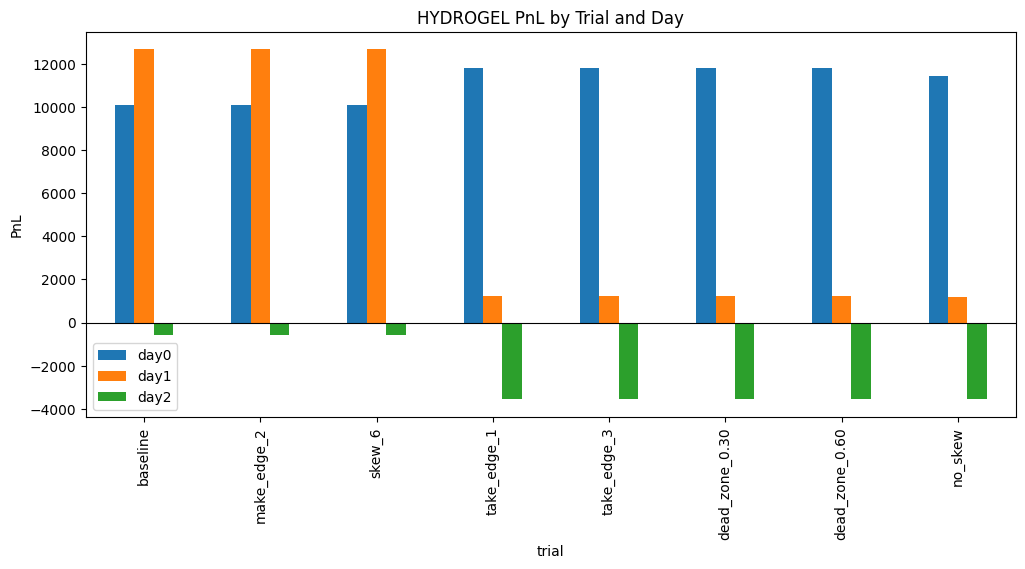

In [11]:
ax = results.set_index("trial")[["day0", "day1", "day2"]].plot(
    kind="bar",
    figsize=(12, 5),
    title="HYDROGEL PnL by Trial and Day",
)
ax.set_ylabel("PnL")
ax.axhline(0, color="black", linewidth=0.8)


## Suggested Next Steps

1. Keep the current baseline in `trader_r3_init.py`: `take=2`, `make=3`, `max_skew=4`, `dead_zone=0.50`, `power=2`.

2. Add lightweight diagnostics before doing more tuning: record HYDROGEL position path, max absolute position, time near limit, number of take fills, and number of passive fills. The backtest PnL alone does not explain why day 2 loses money.

3. Test side-specific passive edges inside `HydrogelStrategy`: when long, widen bid and tighten ask; when short, tighten bid and widen ask. This may be easier to reason about than shifting fair value.

4. Investigate day 2 separately. The baseline already makes good money on days 0 and 1, so the next improvement should target day 2 drawdown rather than chasing more day 0 edge.

5. Treat exact equality between some trials cautiously. It may mean the parameter does not bind in this replay, not that it is irrelevant in the official matching engine.


## Latest Log Review: `413918.log`

I refreshed this notebook with the HYDROGEL visualizer-log analysis from `/Users/yingzhu/Downloads/hydrogel_1/413918.log`.

Key results:

- The log covers Round 3 day 2.
- `HYDROGEL_PACK` has 20 public trade events and 75 total traded units.
- `SUBMISSION` participates in 19 of those trades, 71 units total.
- `SUBMISSION` buys 24 units and sells 47 units, ending net `-23`.
- The position path stays far from the `200` limit: max absolute position is only `25`, or `12.5%` of limit.
- There are `0 / 1000` ticks where `abs(position) >= 100`.

Conclusion: the strategy is not capacity constrained. If we are missing opportunity, it is more likely from quote placement / fill probability than from position limit.

## Interactive Graph Analysis: `413918.log`

This section builds toggleable Plotly charts from `/Users/yingzhu/Downloads/hydrogel_1/413918.log`.

What to inspect:

- **PnL vs position:** whether drawdowns line up with inventory swings.
- **Book / quote placement:** whether our quotes are too far from the touch to get filled.
- **Trade flow:** how sparse HYDROGEL trading is, and whether `SUBMISSION` captures most visible flow.

Use the legend to toggle traces on/off. Double-click a legend item to isolate it.

In [12]:
import csv
import io
import json
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

LOG_PATH = Path("/Users/yingzhu/Downloads/hydrogel_1/413918.log")
SYM = "HYDROGEL_PACK"
LIMIT = 200
DEAD_ZONE_ABS = 100  # 50% of the 200-lot limit used by the nonlinear skew baseline.

data = json.loads(LOG_PATH.read_text())

# --- 1) Market snapshots / PnL from activitiesLog -------------------------
activity = pd.read_csv(io.StringIO(data["activitiesLog"]), sep=";")
hyd_activity = activity.loc[activity["product"] == SYM].copy()
for col in [
    "timestamp", "bid_price_1", "bid_volume_1", "ask_price_1", "ask_volume_1",
    "mid_price", "profit_and_loss",
]:
    hyd_activity[col] = pd.to_numeric(hyd_activity[col], errors="coerce")

# --- 2) State snapshots and submitted orders from lambda logs --------------
state_rows = []
order_rows = []
for rec in data["logs"]:
    payload = json.loads(rec["lambdaLog"])
    state, orders, conversions, trader_data, log_text = payload
    ts = int(state[0])
    position = int(state[6].get(SYM, 0))

    book = state[3].get(SYM, [{}, {}])
    buy_book = {int(k): int(v) for k, v in book[0].items()}
    sell_book = {int(k): int(v) for k, v in book[1].items()}

    best_bid = max(buy_book) if buy_book else None
    best_ask = min(sell_book) if sell_book else None
    wall_bid = max(buy_book, key=buy_book.get) if buy_book else None
    wall_ask = max(sell_book, key=lambda px: abs(sell_book[px])) if sell_book else None
    wall_mid = (wall_bid + wall_ask) / 2 if wall_bid is not None and wall_ask is not None else None

    state_rows.append({
        "timestamp": ts,
        "position": position,
        "abs_position": abs(position),
        "best_bid": best_bid,
        "best_ask": best_ask,
        "wall_bid": wall_bid,
        "wall_ask": wall_ask,
        "wall_mid": wall_mid,
        "spread": (best_ask - best_bid) if best_bid is not None and best_ask is not None else None,
        "book_bid_qty": sum(buy_book.values()),
        "book_ask_qty": sum(abs(v) for v in sell_book.values()),
    })

    for symbol, price, qty in orders:
        if symbol == SYM:
            order_rows.append({
                "timestamp": ts,
                "price": int(price),
                "quantity": int(qty),
                "side": "our_bid" if int(qty) > 0 else "our_ask",
                "abs_quantity": abs(int(qty)),
            })

state_df = pd.DataFrame(state_rows)
order_df = pd.DataFrame(order_rows)

# --- 3) Public trade flow ---------------------------------------------------
trade_df = pd.DataFrame([t for t in data["tradeHistory"] if t["symbol"] == SYM])
if not trade_df.empty:
    trade_df["side"] = trade_df.apply(
        lambda r: "submission_buy" if r["buyer"] == "SUBMISSION"
        else ("submission_sell" if r["seller"] == "SUBMISSION" else "external"),
        axis=1,
    )
    trade_df["signed_submission_qty"] = trade_df.apply(
        lambda r: r["quantity"] if r["buyer"] == "SUBMISSION"
        else (-r["quantity"] if r["seller"] == "SUBMISSION" else 0),
        axis=1,
    )
    trade_df["cum_submission_qty"] = trade_df["signed_submission_qty"].cumsum()

summary = pd.DataFrame([{
    "final_pnl": hyd_activity["profit_and_loss"].iloc[-1],
    "public_trade_events": len(trade_df),
    "public_trade_qty": int(trade_df["quantity"].sum()) if not trade_df.empty else 0,
    "submission_buy_qty": int(trade_df.loc[trade_df["side"] == "submission_buy", "quantity"].sum()) if not trade_df.empty else 0,
    "submission_sell_qty": int(trade_df.loc[trade_df["side"] == "submission_sell", "quantity"].sum()) if not trade_df.empty else 0,
    "final_position": int(state_df["position"].iloc[-1]),
    "max_abs_position": int(state_df["abs_position"].max()),
    "limit_utilization": state_df["abs_position"].max() / LIMIT,
    "ticks_over_dead_zone": int((state_df["abs_position"] >= DEAD_ZONE_ABS).sum()),
    "mean_spread": state_df["spread"].mean(),
}])
display(summary)

# --- Chart 1: PnL and position --------------------------------------------
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=("HYDROGEL PnL", "Position vs Limit / Dead Zone"),
)
fig.add_trace(
    go.Scatter(
        x=hyd_activity["timestamp"],
        y=hyd_activity["profit_and_loss"],
        mode="lines",
        name="PnL",
        line=dict(width=2),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=state_df["timestamp"],
        y=state_df["position"],
        mode="lines",
        name="position",
        line=dict(width=2),
    ),
    row=2,
    col=1,
)
for y, label in [(LIMIT, "+limit"), (-LIMIT, "-limit"), (DEAD_ZONE_ABS, "+dead zone"), (-DEAD_ZONE_ABS, "-dead zone"), (0, "flat")]:
    fig.add_hline(y=y, line_dash="dash" if y else "solid", line_width=1, annotation_text=label, row=2, col=1)
fig.update_layout(
    title="HYDROGEL PnL and Inventory Path",
    height=650,
    hovermode="x unified",
    legend_title_text="Click to toggle",
)
fig.update_yaxes(title_text="PnL", row=1, col=1)
fig.update_yaxes(title_text="Position", row=2, col=1)
fig.update_xaxes(title_text="Timestamp", row=2, col=1)
fig.show()

# --- Chart 2: book, our quotes, and fills ----------------------------------
fig = go.Figure()
fig.add_trace(go.Scatter(x=state_df["timestamp"], y=state_df["best_bid"], mode="lines", name="best_bid", line=dict(width=1)))
fig.add_trace(go.Scatter(x=state_df["timestamp"], y=state_df["best_ask"], mode="lines", name="best_ask", line=dict(width=1)))
fig.add_trace(go.Scatter(x=state_df["timestamp"], y=state_df["wall_mid"], mode="lines", name="wall_mid", line=dict(width=2)))

if not order_df.empty:
    bid_orders = order_df.loc[order_df["side"] == "our_bid"]
    ask_orders = order_df.loc[order_df["side"] == "our_ask"]
    fig.add_trace(go.Scatter(
        x=bid_orders["timestamp"], y=bid_orders["price"], mode="markers", name="our_bid_orders",
        marker=dict(size=5, opacity=0.35),
        customdata=bid_orders[["quantity"]],
        hovertemplate="ts=%{x}<br>price=%{y}<br>qty=%{customdata[0]}<extra></extra>",
    ))
    fig.add_trace(go.Scatter(
        x=ask_orders["timestamp"], y=ask_orders["price"], mode="markers", name="our_ask_orders",
        marker=dict(size=5, opacity=0.35),
        customdata=ask_orders[["quantity"]],
        hovertemplate="ts=%{x}<br>price=%{y}<br>qty=%{customdata[0]}<extra></extra>",
    ))

if not trade_df.empty:
    marker_by_side = {
        "submission_buy": "triangle-up",
        "submission_sell": "triangle-down",
        "external": "x",
    }
    for side, side_df in trade_df.groupby("side"):
        fig.add_trace(go.Scatter(
            x=side_df["timestamp"], y=side_df["price"], mode="markers", name=f"trade_{side}",
            marker=dict(size=10, symbol=marker_by_side.get(side, "circle")),
            customdata=side_df[["quantity", "buyer", "seller"]],
            hovertemplate="ts=%{x}<br>price=%{y}<br>qty=%{customdata[0]}<br>buyer=%{customdata[1]}<br>seller=%{customdata[2]}<extra></extra>",
        ))

fig.update_layout(
    title="HYDROGEL Book, Our Quotes, and Public Trades",
    xaxis_title="Timestamp",
    yaxis_title="Price",
    height=700,
    hovermode="x unified",
    legend_title_text="Click traces to toggle; double-click to isolate",
)
fig.show()

# --- Chart 3: flow / volume -------------------------------------------------
fig = make_subplots(specs=[[{"secondary_y": True}]])
if not trade_df.empty:
    for side, side_df in trade_df.groupby("side"):
        fig.add_trace(
            go.Bar(x=side_df["timestamp"], y=side_df["quantity"], name=f"qty_{side}", opacity=0.75),
            secondary_y=False,
        )
    fig.add_trace(
        go.Scatter(
            x=trade_df["timestamp"],
            y=trade_df["cum_submission_qty"],
            mode="lines+markers",
            name="cum_submission_qty",
            line=dict(width=2),
        ),
        secondary_y=True,
    )
fig.update_layout(
    title="HYDROGEL Public Trade Flow",
    xaxis_title="Timestamp",
    height=500,
    barmode="stack",
    hovermode="x unified",
    legend_title_text="Click to toggle",
)
fig.update_yaxes(title_text="Trade quantity", secondary_y=False)
fig.update_yaxes(title_text="Cumulative SUBMISSION net qty", secondary_y=True)
fig.show()


,final_pnl,public_trade_events,public_trade_qty,submission_buy_qty,submission_sell_qty,final_position,max_abs_position,limit_utilization,ticks_over_dead_zone,mean_spread
0,606.65625,20,75,24,47,-23,25,0.125,0,15.645


### Graph Readout

- **PnL and inventory path:** position never gets close to the 200 limit, so inventory capacity is not the bottleneck in this log. If PnL drops while position stays small, the issue is more likely adverse fills / mark-to-market movement than overuse of limit.
- **Book / quotes / fills:** use the legend to isolate `our_bid_orders`, `our_ask_orders`, and trade markers. If our quote markers sit far away from the best bid/ask for long periods, we are probably quoting too passively to capture more flow.
- **Trade flow:** HYDROGEL public flow is sparse. This means a low position is not automatically bad: there may simply be limited aggressive flow to interact with. The key question is whether the few external/non-submission trades happened at prices we could have reasonably captured.

Next useful diagnostic: compare our submitted quote prices to the next public trade price and side. That would show whether we missed trades because we were one or two ticks too conservative, or because there was no accessible flow.

## PnL Distribution and Drawdown Review: `422610.log`

This section reviews the latest HYDROGEL run from `422610.log`. The original downloaded path may move between machines, so the code below checks both `/Users/yingzhu/Downloads/hydrogel_2/422610.log` and the repo copy at `Round_3/logs/422610.log`.

Key readout from the current log:

- Final `HYDROGEL_PACK` PnL: `606.7`.
- Peak PnL: `1657.0`; ending PnL is also the max-drawdown trough, so max drawdown is `-1050.4` from timestamp `91100` to `99900`.
- PnL range over the run is `1833.8`, much larger than final PnL. This is a volatility problem, not just a low-PnL problem.
- Strategy ends net short `-23`; own HYDROGEL flow is `24` bought vs `47` sold.
- Inventory is not near the official `200` limit, but it is directionally meaningful: max absolute position is `25`, and `315 / 1000` ticks have `abs(position) >= 20`.
- Tick PnL changes correlate strongly with `lag_position * mid_price_change` (`corr ≈ 0.835`, `R² ≈ 0.697`). This means most PnL volatility is inventory mark-to-market, not smooth spread capture.

Implication: increasing PnL while lowering volatility likely requires staying flatter, especially after profitable directional inventory builds. The current adjustment direction is therefore: reduce stale EMA anchor risk, tighten inventory skew earlier, and allow near-fair flattening when the book provides a reasonable exit.

In [13]:
import json
import io
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

SYM = "HYDROGEL_PACK"
LIMIT = 200
LOG_CANDIDATES = [
    Path("/Users/yingzhu/Downloads/hydrogel_2/422610.log"),
    Path("/Users/yingzhu/Desktop/88-Pineapple/Round_3/logs/422610.log"),
]
LOG_PATH = next((p for p in LOG_CANDIDATES if p.exists()), None)
if LOG_PATH is None:
    raise FileNotFoundError(f"Cannot find 422610.log in: {LOG_CANDIDATES}")

raw_log = json.loads(LOG_PATH.read_text())

# --- Market snapshots / PnL -------------------------------------------------
activity = pd.read_csv(io.StringIO(raw_log["activitiesLog"]), sep=";")
hyd = activity.loc[activity["product"] == SYM].copy()
for col in ["timestamp", "mid_price", "profit_and_loss", "bid_price_1", "ask_price_1"]:
    hyd[col] = pd.to_numeric(hyd[col], errors="coerce")
hyd = hyd.sort_values("timestamp").reset_index(drop=True)
hyd["pnl_change"] = hyd["profit_and_loss"].diff().fillna(0.0)
hyd["running_peak"] = hyd["profit_and_loss"].cummax()
hyd["drawdown"] = hyd["profit_and_loss"] - hyd["running_peak"]
hyd["mid_change"] = hyd["mid_price"].diff().fillna(0.0)

# --- Position and submitted orders from lambda logs -------------------------
state_rows = []
order_rows = []
for rec in raw_log["logs"]:
    state, orders, conversions, trader_data, log_text = json.loads(rec["lambdaLog"])
    ts = int(state[0])
    position = int(state[6].get(SYM, 0))
    state_rows.append({
        "timestamp": ts,
        "position": position,
        "abs_position": abs(position),
    })
    for symbol, price, quantity in orders:
        if symbol != SYM:
            continue
        order_rows.append({
            "timestamp": ts,
            "price": int(price),
            "quantity": int(quantity),
            "side": "bid" if int(quantity) > 0 else "ask",
        })

state_df = pd.DataFrame(state_rows)
order_df = pd.DataFrame(order_rows)
path_df = hyd.merge(state_df, on="timestamp", how="left")
path_df["lag_position"] = path_df["position"].shift(1).fillna(0)
path_df["mtm_component"] = path_df["lag_position"] * path_df["mid_change"]

# --- Own HYDROGEL trades ----------------------------------------------------
trades = pd.DataFrame(raw_log["tradeHistory"])
hyd_trades = trades.loc[trades["symbol"] == SYM].copy() if not trades.empty else pd.DataFrame()
own_trades = hyd_trades.loc[
    (hyd_trades["buyer"] == "SUBMISSION") | (hyd_trades["seller"] == "SUBMISSION")
].copy() if not hyd_trades.empty else pd.DataFrame()
if not own_trades.empty:
    own_trades["side"] = np.where(own_trades["buyer"] == "SUBMISSION", "buy", "sell")
    own_trades["signed_qty"] = np.where(
        own_trades["side"] == "buy",
        own_trades["quantity"],
        -own_trades["quantity"],
    )

# --- Metrics ----------------------------------------------------------------
mdd_idx = hyd["drawdown"].idxmin()
trough = hyd.loc[mdd_idx]
peak_idx = hyd.loc[:mdd_idx, "profit_and_loss"].idxmax()
peak = hyd.loc[peak_idx]
mtm_corr = path_df[["pnl_change", "mtm_component"]].dropna().corr().iloc[0, 1]

risk_summary = pd.DataFrame([{
    "log_path": str(LOG_PATH),
    "final_pnl": hyd["profit_and_loss"].iloc[-1],
    "max_pnl": hyd["profit_and_loss"].max(),
    "min_pnl": hyd["profit_and_loss"].min(),
    "pnl_range": hyd["profit_and_loss"].max() - hyd["profit_and_loss"].min(),
    "max_drawdown": hyd["drawdown"].min(),
    "mdd_peak_ts": int(peak["timestamp"]),
    "mdd_trough_ts": int(trough["timestamp"]),
    "final_drawdown": hyd["profit_and_loss"].iloc[-1] - hyd["running_peak"].iloc[-1],
    "pnl_change_std": hyd["pnl_change"].std(),
    "downside_change_std": hyd.loc[hyd["pnl_change"] < 0, "pnl_change"].std(),
    "large_abs_change_gt_50": int((hyd["pnl_change"].abs() > 50).sum()),
    "large_abs_change_gt_100": int((hyd["pnl_change"].abs() > 100).sum()),
    "final_position": int(state_df["position"].iloc[-1]),
    "mean_abs_position": state_df["abs_position"].mean(),
    "max_abs_position": int(state_df["abs_position"].max()),
    "ticks_abs_pos_ge_20": int((state_df["abs_position"] >= 20).sum()),
    "own_trade_count": len(own_trades),
    "own_buy_qty": int(own_trades.loc[own_trades["side"] == "buy", "quantity"].sum()) if not own_trades.empty else 0,
    "own_sell_qty": int(own_trades.loc[own_trades["side"] == "sell", "quantity"].sum()) if not own_trades.empty else 0,
    "net_own_qty": int(own_trades["signed_qty"].sum()) if not own_trades.empty else 0,
    "mtm_corr": mtm_corr,
    "mtm_r2": mtm_corr ** 2,
}])

display(risk_summary.round(4))

pnl_distribution = pd.DataFrame({
    "pnl_level": hyd["profit_and_loss"].quantile([0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]),
    "pnl_change": hyd["pnl_change"].quantile([0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]),
}).rename_axis("quantile")
display(pnl_distribution.round(4))

,log_path,final_pnl,max_pnl,min_pnl,pnl_range,max_drawdown,mdd_peak_ts,mdd_trough_ts,final_drawdown,pnl_change_std,...,final_position,mean_abs_position,max_abs_position,ticks_abs_pos_ge_20,own_trade_count,own_buy_qty,own_sell_qty,net_own_qty,mtm_corr,mtm_r2
0,/Users/yingzhu/Desktop/88-Pineapple/Round_3/lo...,606.6562,1657.0156,-176.7656,1833.7812,-1050.3594,91100,99900,-1050.3594,27.6405,...,-23,11.12,25,315,19,24,47,-23,0.8351,0.6973


,pnl_level,pnl_change
quantile,,
0.00,-176.7656,-113.5469
0.01,-104.2505,-83.4595
0.05,0.0000,-52.1812
0.25,105.6426,-7.0610
0.50,255.0664,0.0000
0.75,703.6172,10.5615
0.95,1282.4266,46.9586
0.99,1521.4655,79.4833
1.00,1657.0156,113.0625


In [14]:
# --- Interactive PnL risk charts -------------------------------------------
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=(
        "HYDROGEL PnL and Running Peak",
        "Drawdown from Running Peak",
        "Position and Inventory-Driven MTM Component",
    ),
)
fig.add_trace(
    go.Scatter(x=hyd["timestamp"], y=hyd["profit_and_loss"], mode="lines", name="PnL"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=hyd["timestamp"], y=hyd["running_peak"], mode="lines", name="running_peak", line=dict(dash="dash")),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=hyd["timestamp"], y=hyd["drawdown"], mode="lines", name="drawdown", fill="tozeroy"),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(x=path_df["timestamp"], y=path_df["position"], mode="lines", name="position"),
    row=3,
    col=1,
)
fig.add_trace(
    go.Bar(x=path_df["timestamp"], y=path_df["mtm_component"], name="lag_position * mid_change", opacity=0.45),
    row=3,
    col=1,
)
fig.add_hline(y=0, line_width=1, row=2, col=1)
fig.add_hline(y=0, line_width=1, row=3, col=1)
fig.update_layout(
    title="HYDROGEL 422610: PnL, Drawdown, and Inventory MTM",
    height=850,
    hovermode="x unified",
)
fig.update_yaxes(title_text="PnL", row=1, col=1)
fig.update_yaxes(title_text="Drawdown", row=2, col=1)
fig.update_yaxes(title_text="Position / MTM", row=3, col=1)
fig.update_xaxes(title_text="Timestamp", row=3, col=1)
fig.show()

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Distribution of PnL Levels", "Distribution of Tick PnL Changes"),
)
fig.add_trace(go.Histogram(x=hyd["profit_and_loss"], nbinsx=40, name="PnL level"), row=1, col=1)
fig.add_trace(go.Histogram(x=hyd["pnl_change"], nbinsx=50, name="PnL change"), row=1, col=2)
fig.update_layout(
    title="HYDROGEL PnL Distribution Diagnostics",
    height=450,
    bargap=0.05,
    showlegend=False,
)
fig.update_xaxes(title_text="PnL", row=1, col=1)
fig.update_xaxes(title_text="PnL change per tick", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.show()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=path_df["mtm_component"],
        y=path_df["pnl_change"],
        mode="markers",
        name="ticks",
        marker=dict(size=6, opacity=0.45),
        text=path_df["timestamp"],
        hovertemplate="timestamp=%{text}<br>MTM proxy=%{x:.2f}<br>PnL change=%{y:.2f}<extra></extra>",
    )
)
fig.add_trace(
    go.Scatter(
        x=[path_df["mtm_component"].min(), path_df["mtm_component"].max()],
        y=[path_df["mtm_component"].min(), path_df["mtm_component"].max()],
        mode="lines",
        name="y = x reference",
        line=dict(dash="dash"),
    )
)
fig.update_layout(
    title=f"PnL Change vs Inventory MTM Proxy (corr={mtm_corr:.3f})",
    xaxis_title="lag_position * mid_price_change",
    yaxis_title="PnL change",
    height=500,
)
fig.show()

### Risk Readout and Tuning Implications

The large drawdown is mostly an inventory MTM problem. In `422610.log`, the strategy builds a persistent short (`final_position = -23`) and benefits while HYDROGEL falls, but gives back a large part of the peak PnL when price rebounds into the close. The max drawdown is exactly the fall from the peak at `t=91100` to the final tick, which means the strategy did not lock in gains after the favorable move.

What the metrics imply:

- **Increase PnL:** keep taking clear edge, but avoid stale EMA anchors that create single-sided inventory when price keeps moving. A fair value closer to live `wall_mid` should reduce adverse mark-to-market while preserving spread capture.
- **Lower PnL volatility:** flatten inventory earlier. The `mtm_corr ≈ 0.835` shows that reducing average and tail inventory should directly reduce PnL swings.
- **Reduce drawdown:** add near-fair flattening after profitable inventory builds. If the strategy is already short and the market offers asks near fair value, buying back part of the short can lock in gains before a rebound.
- **Inventory skew:** the old 50% dead zone is too loose for a strategy whose PnL volatility is dominated by inventory. A smaller dead zone and larger skew should keep the strategy closer to flat.

Suggested next experiment: compare the current `trader_r3_2.py` flatter version against this log's run, and track not only final PnL but also `max_drawdown`, `pnl_change_std`, `mean_abs_position`, `ticks_abs_pos_ge_20`, and `mtm_corr`. A better version should ideally keep final PnL competitive while cutting max drawdown and high-absolute-position time.